### 파일 불러오기

In [1]:
import os
os.getcwd()
os.chdir('C:\\Users\\홍은유\\Documents')

In [2]:
import pandas as pd
pd.set_option('display.max_rows', None)

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

### 데이터 살펴보기

In [3]:
train.info()
train.shape

train.isna().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID                               748 non-null    object 
 1   generation                       748 non-null    int64  
 2   school1                          748 non-null    int64  
 3   major type                       726 non-null    object 
 4   major1_1                         728 non-null    object 
 5   major1_2                         309 non-null    object 
 6   major_data                       748 non-null    bool   
 7   job                              748 non-null    object 
 8   class1                           748 non-null    int64  
 9   class2                           169 non-null    float64
 10  class3                           14 non-null     float64
 11  class4                           1 non-null      float64
 12  re_registration       

contest_award                      748
idea_contest                       748
class4                             747
contest_participation              742
class3                             734
previous_class_5                   602
previous_class_3                   602
previous_class_6                   602
previous_class_8                   602
previous_class_7                   602
previous_class_4                   602
class2                             579
major1_2                           439
completed_semester                  28
major_field                         23
major type                          22
major1_1                            20
nationality                          1
incumbents_level                     0
incumbents_lecture                   0
desired_job_except_data              0
incumbents_lecture_scale_reason      0
incumbents_company_level             0
incumbents_lecture_type              0
incumbents_lecture_scale             0
certificate_acquisition  

##### 결측치

In [4]:
train.isnull().sum().sort_values(ascending=False)
train_missing = train.isnull().sum() / 748
train_missing.sort_values(ascending=False)

contest_award                      1.000000
idea_contest                       1.000000
class4                             0.998663
contest_participation              0.991979
class3                             0.981283
previous_class_5                   0.804813
previous_class_3                   0.804813
previous_class_6                   0.804813
previous_class_8                   0.804813
previous_class_7                   0.804813
previous_class_4                   0.804813
class2                             0.774064
major1_2                           0.586898
completed_semester                 0.037433
major_field                        0.030749
major type                         0.029412
major1_1                           0.026738
nationality                        0.001337
incumbents_level                   0.000000
incumbents_lecture                 0.000000
desired_job_except_data            0.000000
incumbents_lecture_scale_reason    0.000000
incumbents_company_level        

####### 결측치 비율이 높은 변수들 중, 결측여부와 수료여부가 관계가 있는지 확인

In [5]:
from scipy.stats import chi2_contingency 

results = []

for col in train.columns:
    if train[col].isna().mean() > 0.5 :  # 결측 비율 기준
        miss_col = f'{col}_missing'
        train[miss_col] = train[col].isna().astype(int)

        rate = train.groupby(miss_col)['completed'].mean()
        diff = abs(rate.get(1, 0) - rate.get(0, 0))

        contingency = pd.crosstab(train[miss_col], train['completed'])
        _, p, _, _ = chi2_contingency(contingency)

        results.append({
            'variable': col,
            'missing_rate': train[col].isna().mean(),
            'completion_rate_diff': diff,
            'p_value': p                 # p값 < 0.05 = 결측여부와 수료여부가 독립이 아님(관계가 있음)
        })

summary = pd.DataFrame(results).sort_values(
    'completion_rate_diff', ascending=False
)

summary.head(13)



,variable,missing_rate,completion_rate_diff,p_value
3,class4,0.998663,0.298527,1.000000
4,contest_award,1.000000,0.298128,1.000000
12,idea_contest,1.000000,0.298128,1.000000
11,contest_participation,0.991979,0.203504,0.523921
5,previous_class_3,0.804813,0.140195,0.001276
6,previous_class_4,0.804813,0.140195,0.001276
7,previous_class_5,0.804813,0.140195,0.001276
8,previous_class_6,0.804813,0.140195,0.001276
9,previous_class_7,0.804813,0.140195,0.001276
10,previous_class_8,0.804813,0.140195,0.001276


####### 결측비율 0.5 초과 & p값 0.05 초과 => 버림

####### 버릴 변수 : class2, class3, class4, contest_award, idea_contest, contest_participation, major1_2   
근데 major1_2 (제2전공) 변수는 버리지 않고 제1전공과 제2전공에서 전공분야가 IT이냐 변수를 만든후 제1전공&제2전공변수 버릴거임

####### previous_class_3~8 변수는 p값은 0.05 미만이지만 결측비율이 0.8이 넘으므로 버리기

####### completed_semester, major_field, major type, major1_1, nationality  이 변수들은 결측값 처리 해줘야함

In [6]:
# train.loc[:,['previous_class_3','previous_class_4','previous_class_5','previous_class_6','previous_class_7','previous_class_8','completed']]

####### 버릴 변수들 버리고 다시 데이터 저장 --> train_filtered_1

In [7]:
train = train.drop(columns=train.filter(like='_missing').columns)

exclude_cols = [
    'class2', 'class3', 'class4', 
    'contest_award', 
    'idea_contest', 
    'contest_participation',
    'previous_class_3','previous_class_4','previous_class_5','previous_class_6','previous_class_7','previous_class_8'
]

train_filtered_1 = train.drop(columns=exclude_cols)

In [8]:
train_filtered_1.head()
train_filtered_1.shape

(748, 34)

####### nationality (내국인/외국인) 변수가 결측치인 행 제거 --> train_filtered_2

In [9]:
train_filtered_2 = train_filtered_1.dropna(subset=['nationality'])
train_filtered_2.shape

(747, 34)

####### school1(대학교) 변수가 0이 아닌 행의 completed_semester (이수학기) 변수의 결측치는 평균값으로 대체  - 이수학기 이상치 처리한 후

In [10]:
train_filtered_2['completed_semester'].describe()

count      719.000000
mean        65.204478
std       1068.965143
min          0.000000
25%          5.000000
50%          6.000000
75%          8.000000
max      20241.000000
Name: completed_semester, dtype: float64

In [11]:
train_filtered_2.isna().sum().sort_values(ascending=False)

major1_2                           439
completed_semester                  28
major_field                         23
major type                          22
major1_1                            20
incumbents_company_level             0
certificate_acquisition              0
desired_certificate                  0
desired_job_except_data              0
incumbents_level                     0
incumbents_lecture                   0
incumbents_lecture_scale             0
incumbents_lecture_type              0
time_input                           0
incumbents_lecture_scale_reason      0
interested_company                   0
expected_domain                      0
onedayclass_topic                    0
desired_job                          0
ID                                   0
project_type                         0
generation                           0
desired_career_path                  0
hope_for_group                       0
what_to_gain                         0
whyBDA                   

####### 대학교를 진학하지 않은 사람의 복수전공여부,제1전공,전공분야,이수학기 변수 결측치는 '없음'으로.. 

In [12]:
train_school_0 = train_filtered_2[train_filtered_2['school1'] == 0]
train_school_0[['school1','major type','major_field','major1_1','major1_2','completed_semester','completed']]
train_school_0.shape

(24, 34)

In [13]:
train_completed_semester = train_filtered_2[train_filtered_2['completed_semester'].isna()]
train_completed_semester[['school1','major type','major_field','major1_1','major1_2','completed_semester']]

,school1,major type,major_field,major1_1,major1_2,completed_semester
50,0,NaN,NaN,NaN,NaN,NaN
89,2,"복수 전공 ( 다중전공, 이중전공 포함 )",인문학,인문학,자연과학,NaN
91,0,NaN,NaN,NaN,NaN,NaN
102,0,NaN,NaN,NaN,NaN,NaN
166,1,NaN,NaN,경제통상학,IT(컴퓨터 공학 포함),NaN
187,4,"복수 전공 ( 다중전공, 이중전공 포함 )",자연고학,자연과학,IT(컴퓨터 공학 포함),NaN
205,0,NaN,NaN,NaN,NaN,NaN
264,0,NaN,NaN,NaN,NaN,NaN
280,0,NaN,NaN,NaN,NaN,NaN
290,3,단일 전공공학 (컴퓨터 공학 제외),NaN,IT(컴퓨터 공학 포함),NaN,NaN


##### 이상치, 틀린값 

In [14]:
train_filtered_2.describe()

,generation,school1,class1,completed_semester,time_input,completed
count,747.0,747.000000,747.000000,719.000000,747.000000,747.000000
mean,9.0,27.945114,4.959839,65.204478,2.325569,0.298527
std,0.0,21.393064,3.402569,1068.965143,1.366617,0.457919
min,9.0,0.000000,1.000000,0.000000,0.000000,0.000000
25%,9.0,13.000000,2.000000,5.000000,2.000000,0.000000
50%,9.0,24.000000,4.000000,6.000000,2.000000,0.000000
75%,9.0,38.000000,7.000000,8.000000,3.000000,1.000000
max,9.0,91.000000,13.000000,20241.000000,24.000000,1.000000


####### 이상한 변수 : completed_semester(20241값안됨), time_input(24안됨)

####### completed_semester (이수학기) 변수 - 최대 8학기까지로 이상치 고침

c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\Lib

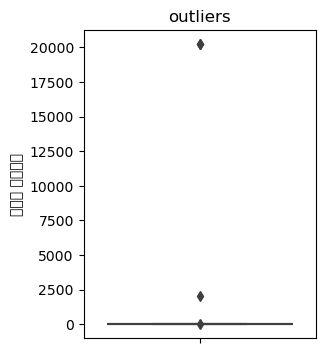

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(3,4))

sns.boxplot(y = train_filtered_2['completed_semester'])

plt.ylabel('대학교 이수학기') 
plt.title('outliers')
plt.show()

In [16]:
t_cs = train_filtered_2[train_filtered_2['completed_semester'] > 8]
t_cs['completed_semester']        # 확인결과 - 이수학기가 8 초과인 행 여러개 존재

# completed_semester가 8보다 큰 행을 찾아 8로 변경
train_filtered_2.loc[train_filtered_2['completed_semester'] > 8 , 'completed_semester'] = 8

####### time_input (하루에 가능한 시간) 변수 - 이상치(24시간)을 평균값으로 바꿈

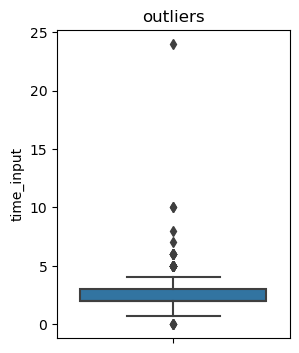

In [17]:
plt.figure(figsize=(3,4))

sns.boxplot(y = train_filtered_2['time_input'])

plt.ylabel('time_input') 
plt.title('outliers')
plt.show()

In [18]:
time_input_mean = train_filtered_2['time_input'].mean()

train_filtered_2.loc[train_filtered_2['time_input'] > 10 , 'time_input'] = time_input_mean

####### 대학교 0이 아닌데 이수학기 결측치 -> 평균값으로 대체

In [19]:
cs_mean = train_filtered_2['completed_semester'].mean()
print(cs_mean)   # 평균 6학기 

sch_cs = (train_filtered_2['school1'] != 0) & (train_filtered_2['completed_semester'].isna())
train_filtered_2.loc[sch_cs, 'completed_semester'] = 6

6.072322670375522


####### 대학교 0 이고, 'major type','major_field','major1_1','major1_2','completed_semester' 변수 모두 결측치 --> '없음'  

In [20]:
cols = [
    'major type',
    'major_field',
    'major1_1',
    'major1_2',
    'completed_semester'
]

sch0 = (train_filtered_2['school1'] == 0) & (train_filtered_2[cols].isna().all(axis=1))

train_filtered_2.loc[sch0, cols] = '없음'

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\3919483830.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '없음' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  train_filtered_2.loc[sch0, cols] = '없음'


In [21]:
train_filtered_2.isna().sum().sort_values(ascending=False)  # 처리해줘야하는 결측치 변수 : major type(2개) / major_field(3개)

#train_filtered_2['major type'].value_counts()

major1_2                           419
major_field                          3
major type                           2
ID                                   0
incumbents_company_level             0
certificate_acquisition              0
desired_certificate                  0
desired_job_except_data              0
incumbents_level                     0
incumbents_lecture                   0
incumbents_lecture_type              0
time_input                           0
incumbents_lecture_scale             0
incumbents_lecture_scale_reason      0
interested_company                   0
expected_domain                      0
onedayclass_topic                    0
desired_job                          0
completed_semester                   0
project_type                         0
generation                           0
desired_career_path                  0
hope_for_group                       0
what_to_gain                         0
whyBDA                               0
inflow_route             

In [22]:
mf = train_filtered_2[train_filtered_2['major_field'].isna()]
mf[['ID','school1','major type','major_field','major1_1','major1_2']]

,ID,school1,major type,major_field,major1_1,major1_2
166,TRAIN_166,1,NaN,NaN,경제통상학,IT(컴퓨터 공학 포함)
290,TRAIN_290,3,단일 전공공학 (컴퓨터 공학 제외),NaN,IT(컴퓨터 공학 포함),NaN
393,TRAIN_393,7,NaN,NaN,IT(컴퓨터 공학 포함),NaN


####### major type 변수에 유일하게 1개 있는 단일 전공공학(컴퓨터 공학 제외) --> 단일전공 으로 바꿔줌

166번은 복수전공이고, 393번은 단일전공으로 결측치 처리

In [23]:
train_filtered_2.loc[166, 'major type'] = '복수 전공 ( 다중전공, 이중전공 포함 )'
train_filtered_2.loc[393, 'major type'] = '단일 전공'
train_filtered_2.loc[290, 'major type'] = '단일 전공'

In [24]:
train_filtered_2.loc[[166,290,393],['major1_1','major1_2','major_field']]

,major1_1,major1_2,major_field
166,경제통상학,IT(컴퓨터 공학 포함),NaN
290,IT(컴퓨터 공학 포함),NaN,NaN
393,IT(컴퓨터 공학 포함),NaN,NaN


####### major_field 변수의 결측치는 전공과목을 보고 채워주기

In [25]:
train_filtered_2.loc[[290,393], 'major_field'] = 'IT (컴퓨터 공학 포함)'
train_filtered_2.loc[[166], 'major_field'] = 'IT (컴퓨터 공학 포함), 경제통상학'

# t=train_filtered_2[(train_filtered_2['major1_1']=='경제통상학') & (train_filtered_2['major1_2']=='IT(컴퓨터 공학 포함)')]
# t[['major1_1','major1_2','major_field']]     # 전공1이 경제통상학 & 전공2가 IT 일 때 전공분야를 IT,경제통상학 / IT,사회과학 등 다양하게 씀.. 

#train_filtered_2['major_field'].unique()

In [26]:
### test 데이터

# 1 결측치 많고 필요없는 변수 삭제
test_filtered_1 = test.drop(columns=exclude_cols)

# 2 내/외국인 변수 결측치인 행 삭제
test_filtered_2 = test_filtered_1.dropna(subset = ['nationality'])

# 5 이수학기 8 초과 -> 8 
test_filtered_2.loc[test_filtered_2['completed_semester'] > 8 , 'completed_semester'] = 8

# 6 time_input 10 초과 값 -> 평균값 
time_input_mean_2 = test_filtered_2['time_input'].mean()

test_filtered_2.loc[test_filtered_2['time_input'] > 10 , 'time_input'] = time_input_mean_2

# 3 대학교번호 0 아닌데 이수학기 결측치 -> 평균값(6) 대체 
cs_mean2 = test_filtered_2['completed_semester'].mean()
print(cs_mean2)   # 평균 6학기 
sch_cs2 = (test_filtered_2['school1'] != 0) & (test_filtered_2['completed_semester'].isna())
test_filtered_2.loc[sch_cs2, 'completed_semester'] = 6
 
# 4 대학교 0 이고, 'major type','major_field','major1_1','major1_2','completed_semester' 변수 모두 결측치 -> '없음'
sch02 = (test_filtered_2['school1'] == 0) & (test_filtered_2[cols].isna().all(axis=1))
test_filtered_2.loc[sch02, cols] = '없음'

# 7,8 복수전공 여부 , 전공 분야 결측치 채워주기
mf2 = test_filtered_2[test_filtered_2['major_field'].isna()]
print(mf2[['ID','school1','major type','major_field','major1_1','major1_2']])

test_filtered_2['major type'].value_counts(dropna=False)

test_filtered_2.loc[344, 'major type'] = '단일 전공'
test_filtered_2.loc[344, 'major_field'] = '의상학과'

6.066216216216216
           ID  school1 major type major_field major1_1 major1_2
344  TEST_344       22        NaN         NaN     의상학과      NaN


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\3995473035.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '없음' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  test_filtered_2.loc[sch02, cols] = '없음'


### 결측치 , 이상치, 틀린값 모두 처리 끝

In [27]:
train_filtered_2.isna().sum().sort_values(ascending=False)

major1_2                           419
ID                                   0
incumbents_company_level             0
desired_job                          0
certificate_acquisition              0
desired_certificate                  0
desired_job_except_data              0
incumbents_level                     0
incumbents_lecture                   0
incumbents_lecture_type              0
project_type                         0
incumbents_lecture_scale             0
incumbents_lecture_scale_reason      0
interested_company                   0
expected_domain                      0
onedayclass_topic                    0
time_input                           0
completed_semester                   0
generation                           0
desired_career_path                  0
major_field                          0
hope_for_group                       0
what_to_gain                         0
whyBDA                               0
inflow_route                         0
nationality              

In [28]:
test_filtered_2.isna().sum().sort_values(ascending=False)

major1_2                           110
ID                                   0
incumbents_lecture                   0
time_input                           0
desired_job                          0
certificate_acquisition              0
desired_certificate                  0
desired_job_except_data              0
incumbents_level                     0
incumbents_company_level             0
completed_semester                   0
incumbents_lecture_type              0
incumbents_lecture_scale             0
incumbents_lecture_scale_reason      0
interested_company                   0
expected_domain                      0
project_type                         0
desired_career_path                  0
generation                           0
major_field                          0
hope_for_group                       0
what_to_gain                         0
whyBDA                               0
inflow_route                         0
nationality                          0
re_registration          

### 피쳐 엔지니어링

In [29]:
train2 = train_filtered_2  # 전처리 한 것 --> train2 에 저장

In [30]:
train_filtered_2.shape

(747, 34)

In [31]:
# 재등록여부 변수 : 예 = 1 , 아니요 = 0
train2['re_registration'] = train2['re_registration'].map({ '예': 1, '아니요': 0 })
train2['re_registration'].value_counts(dropna=False)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\2607824357.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['re_registration'] = train2['re_registration'].map({ '예': 1, '아니요': 0 })


re_registration
0    601
1    146
Name: count, dtype: int64

In [32]:
train2['nationality'].value_counts(dropna=False)

nationality
내국인    745
외국인      2
Name: count, dtype: int64

In [33]:
# 이수학기 변수 : 0(없음) , 1(0~2) , 2(3~4) , 3(5~6) , 4(7~8)  -> cs_category

def categorize_completed_semester(cs) :
    if cs == '없음' : 
        return 0
    elif cs in [0 , 1 , 2] :
        return 1
    elif cs in [3 , 4] :
        return 2
    elif cs in [5 , 6] :
        return 3
    else:
        return 4
    
train2['cs_category'] = train2['completed_semester'].apply(categorize_completed_semester)

train2['cs_category'].value_counts(dropna=False)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\2298037843.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['cs_category'] = train2['completed_semester'].apply(categorize_completed_semester)


cs_category
4    298
3    253
2    144
1     32
0     20
Name: count, dtype: int64

In [34]:
# time_input 변수 : 0(0) , 1(1~3) , 2(4~6) , 3(7~10)  -> ti_category

def categorize_time_input(ti) :
    if ti == 0 : 
        return 0
    elif ti <= 3 :
        return 1
    elif ti <= 6 :
        return 2
    else:
        return 3
    
train2['ti_category'] = train2['time_input'].apply(categorize_time_input)

train2['ti_category'].value_counts(dropna=False)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\427795027.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['ti_category'] = train2['time_input'].apply(categorize_time_input)


ti_category
1    653
2     86
3      4
0      4
Name: count, dtype: int64

In [35]:
# 유입경로 변수 : sns(에브리타임,인스타그램,교내플랫폼,기타), 기존(기존 학회원 또는 운영진), 지인추천(지인추천), 검색(인터넷검색,대외활동사이트)  -> ir_category

def categorize_inflow_route(x):
    x = str(x).lower()

    if any(k in x for k in ['에브리타임', '인스타그램', '교내 플랫폼']):
        return 'sns'
    elif any(k in x for k in ['기존']):
        return '기존회원'
    elif any(k in x for k in ['지인 추천']):
        return '지인추천'
    elif any(k in x for k in ['검색', '대외활동']):
        return '검색'
    else:
        return 'sns'
    
train2['ir_category'] = train2['inflow_route'].apply(categorize_inflow_route)

train2['ir_category'].value_counts(dropna=False)
    

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\3656473185.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['ir_category'] = train2['inflow_route'].apply(categorize_inflow_route)


ir_category
sns     463
기존회원    150
지인추천     78
검색       56
Name: count, dtype: int64

In [36]:
# 왜BDA 변수 : 관리(혼자공부어려움, 큰규모라서관리잘됨), 만족(이전기수에만족), 혜택(학회원만의 혜택, 현직자강의), 부담없음(시간적부담없음,입단시험없음)  -> wB_category

def categorize_whyBDA(x):
    x = str(x).lower()

    if any(k in x for k in ['혼자', '관리']):
        return '관리'
    elif any(k in x for k in ['이전 기수']):
        return '만족'
    elif any(k in x for k in ['혜택','현직자']):
        return '혜택'
    elif any(k in x for k in ['부담', '테스트']):
        return '부담없음'
    
train2['wB_category'] = train2['whyBDA'].apply(categorize_whyBDA)

train2['wB_category'].value_counts(dropna=False)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\1706182838.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['wB_category'] = train2['whyBDA'].apply(categorize_whyBDA)


wB_category
관리      430
만족      146
혜택      120
부담없음     51
Name: count, dtype: int64

In [37]:
# 조별활동 희망여부 변수 : 온라인그룹(네.온라인으로) , 오프라인그룹(네.오프라인으로) , 개인(아니요.개인적으로)  -> hg_category

def categorize_hope_for_group(x):
    x = str(x).lower()

    if any(k in x for k in ['오프라인']):
        return '오프라인그룹'
    elif any(k in x for k in ['온라인']):
        return '온라인그룹'
    elif any(k in x for k in ['개인']):
        return '개인'
    
train2['hg_category'] = train2['hope_for_group'].apply(categorize_hope_for_group)

train2['hg_category'].value_counts(dropna=False)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\688074202.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['hg_category'] = train2['hope_for_group'].apply(categorize_hope_for_group)


hg_category
오프라인그룹    367
온라인그룹     264
개인        116
Name: count, dtype: int64

In [38]:
train2['desired_career_path'].value_counts(dropna=False)

desired_career_path
취업        572
대학원 진학    143
이직         24
창업          8
Name: count, dtype: int64

In [39]:
# BDA에서 얻고 싶은 것 (what_to_gain) : 데이터분석역량 , 경험 , 인적네트워크  -> wtg_category
# 테스트 데이터에서 기타 별로 없으면 else 에 '경험' 해서 '기타' 없애기

def categorize_what_to_gain(x):
    x = str(x).lower()

    if any(k in x for k in ['분석 역량']):
        return '데이터분석역량'
    elif any(k in x for k in ['공모전','프로젝트','경험','전체']):
        return '경험'
    elif any(k in x for k in ['인적 네트워크']):
        return '인적네트워크'
    else :
        return '경험'
    
train2['wtg_category'] = train2['what_to_gain'].apply(categorize_what_to_gain)

train2['wtg_category'].value_counts(dropna=False)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\1897822694.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['wtg_category'] = train2['what_to_gain'].apply(categorize_what_to_gain)


wtg_category
데이터분석역량    493
경험         225
인적네트워크      29
Name: count, dtype: int64

In [40]:
print(train2['project_type'].value_counts(dropna=False))
print('---')
print(train2['nationality'].value_counts(dropna=False))

project_type
팀     527
개인    220
Name: count, dtype: int64
---
nationality
내국인    745
외국인      2
Name: count, dtype: int64


In [41]:
# 희망직무 변수(desired_job) : 1 (데이터관련O) / 0 (데이터관련X)  -> job_category 
# 밑에 데이터 외 희망직종에 'PM/서비스기획자','소프트웨어'가 있어서 이 직업은 데이터관련X으로 분류

def categorize_desired_job(x):
    x = str(x).lower()

    if any(k in x for k in ['데이터','인공지능']):
        return 1     # 데이터관련O
    else :
        return 0     # 데이터관련X
    
train2['job_category'] = train2['desired_job'].apply(categorize_desired_job)

train2['job_category'].value_counts(dropna=False)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\1875511470.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['job_category'] = train2['desired_job'].apply(categorize_desired_job)


job_category
1    612
0    135
Name: count, dtype: int64

In [42]:
train2.shape

(747, 41)

In [43]:
# 취득한 자격증 (certificate_acquisition) : 0(없음,준비중) , 1(1개,기타), 2(2개이상)  -> cert_level 

def certificate_level(x):
    if pd.isna(x):
        return 0

    x = str(x).strip()

    # 취득한 자격증 없음
    if any(k in x for k in ['없음', '준비중']):
        return 0

    # 자격증 개수 계산
    cnt = len([c for c in x.split(',') if c.strip() != ''])

    if cnt == 1:
        return 1
    else:
        return 2
    
train2['cert_level'] = train2['certificate_acquisition'].apply(certificate_level)
train2['cert_level'].value_counts(dropna=False)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\2012620109.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['cert_level'] = train2['certificate_acquisition'].apply(certificate_level)


cert_level
0    466
1    181
2    100
Name: count, dtype: int64

In [44]:
# 취득하고 싶은 자격증 (desired_certificate) : 1 (데이터관련O(데이터, ADsP, SQLD, 정보)) , 0 (데이터관련X)  -> dc_category

def categorize_desired_certificate(x):
    x = str(x).strip()

    if any(k in x for k in ['데이터', 'ADsP', 'SQLD', '정보']):
        return 1      # 데이터관련O
    else:
        return 0      # 데이터관련X
    
train2['dc_category'] = train2['desired_certificate'].apply(categorize_desired_certificate)
train2['dc_category'].value_counts(dropna=False)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\3706450552.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['dc_category'] = train2['desired_certificate'].apply(categorize_desired_certificate)


dc_category
1    711
0     36
Name: count, dtype: int64

In [45]:
# 데이터 외 희망직종 (desired_job_except_data) : 1 (IT관련O) , 0 (IT관련X)  -> edjob_category

def categorize_desired_job_except_data(x):
    x = str(x).strip()

    if any(k in x for k in ['소프트웨어', 'PM', 'UX']):
        return 1     # IT관련O
    else:
        return 0     # IT관련X
    
train2['edjob_category'] = train2['desired_job_except_data'].apply(categorize_desired_job_except_data)
train2['edjob_category'].value_counts(dropna=False)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\999475649.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['edjob_category'] = train2['desired_job_except_data'].apply(categorize_desired_job_except_data)


edjob_category
1    406
0    341
Name: count, dtype: int64

In [46]:
# 현직자 강의 주제 (incumbents_lecture) : 커리어패스과정 , 직무강의 , 산업트렌드  -> il_category
 
def categorize_incumbents_lecture(x):
    x = str(x).strip()

    if any(k in x for k in ['커리어','취업']):
        return '커리어패스과정'
    elif any(k in x for k in ['직무 강의']) :
        return '직무강의'
    elif any(k in x for k in ['산업 트렌드']) :
        return '산업트렌드'
    else:
        return '커리어패스과정'
    
train2['il_category'] = train2['incumbents_lecture'].apply(categorize_incumbents_lecture)
train2['il_category'].value_counts(dropna=False)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\1299326510.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['il_category'] = train2['incumbents_lecture'].apply(categorize_incumbents_lecture)


il_category
커리어패스과정    390
직무강의       285
산업트렌드       72
Name: count, dtype: int64

In [47]:
# 현직자 회사 규모 (incumbents_company_level) : 국내대기업IT , 국내빅테크IT , 해외기업 , 기타  -> icl_category

def categorize_incumbents_company_level(x):
    x = str(x).strip()

    if any(k in x for k in ['국내 대기업 IT']):
        return '국내대기업IT'
    elif any(k in x for k in ['국내 빅테크 IT']) :
        return '국내빅테크IT'
    elif any(k in x for k in ['해외 기업']) :
        return '해외기업'
    else:
        return '기타'
    
train2['icl_category'] = train2['incumbents_company_level'].apply(categorize_incumbents_company_level)
train2['icl_category'].value_counts(dropna=False)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\667033652.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['icl_category'] = train2['incumbents_company_level'].apply(categorize_incumbents_company_level)


icl_category
국내대기업IT    298
국내빅테크IT    283
해외기업       114
기타          52
Name: count, dtype: int64

In [48]:
# 현직자 강의 규모 (incumbents_lecture_scale) : 10명내외리스너 / 50명내외리스너(기타포함) / 100명이상리스너  -> ils_category  
# 만약에 테스트 데이터에 기타 별로 없으면 그냥 기타 없애기  

def categorize_incumbents_lecture_scale(x):
    x = str(x).strip()

    if any(k in x for k in ['10명 내외']):
        return '10명내외리스너'
    elif any(k in x for k in ['50명 내외']) :
        return '50명내외리스너'
    elif any(k in x for k in ['100명 이상']) :
        return '100명이상리스너'
    else:
        return '50명내외리스너'
    
train2['ils_category'] = train2['incumbents_lecture_scale'].apply(categorize_incumbents_lecture_scale)
train2['ils_category'].value_counts(dropna=False)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\3992506470.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['ils_category'] = train2['incumbents_lecture_scale'].apply(categorize_incumbents_lecture_scale)


ils_category
50명내외리스너     441
100명이상리스너    201
10명내외리스너     105
Name: count, dtype: int64

In [49]:
# 관심있는 기업 (interested_company) : 1(있음) , 0(없음)  --> ic_category   

def categorize_interested_company(x):
    x = str(x).strip()

    if any(k in x for k in ['.','없','찾']):
        return 0     # 없음
    else:
        return 1     # 있음
    
train2['ic_category'] = train2['interested_company'].apply(categorize_interested_company)
train2['ic_category'].value_counts(dropna=False)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\733955801.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['ic_category'] = train2['interested_company'].apply(categorize_interested_company)


ic_category
1    660
0     87
Name: count, dtype: int64

In [50]:
# 희망하는 도메인 (expected_domain) : 1 (데이터중요O) , 0 (데이터중요X)  -> ed_category

def categorize_expected_domain(x):
    x = str(x).strip()

    if any(k in x for k in ['J','K','M']):
        return 1    # 데이터중요O
    else:
        return 0    # 데이터중요X
    
train2['ed_category'] = train2['expected_domain'].apply(categorize_expected_domain)
train2['ed_category'].value_counts(dropna=False)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\2005673607.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['ed_category'] = train2['expected_domain'].apply(categorize_expected_domain)


ed_category
1    598
0    149
Name: count, dtype: int64

In [51]:
# 전공분야 (major_field) : 1 (IT관련O) , 0 (IT관련X)  -> mf_category 
# major1_1 , major1_2 , major_data 변수들은 삭제
# test 데이터에는 train 데이터와 달리, 제1,2전공이 IT 관련 이렇게 되어있지 않아서 전공분야(major_field)를 기준으로 나눔 

def categorize_major_field(x):
    x = str(x).strip()

    if any(k in x for k in ['IT']):
        return 1                     # IT관련O
    else:
        return 0                     # IT관련X
    
train2['mf_category'] = train2['major_field'].apply(categorize_major_field)
train2['mf_category'].value_counts(dropna=False)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\3997874864.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['mf_category'] = train2['major_field'].apply(categorize_major_field)


mf_category
0    561
1    186
Name: count, dtype: int64

In [52]:
print(train2['generation'].value_counts(dropna=False))  # 기수 - 전부 9
print('---')
print(train2['class1'].value_counts(dropna=False))  # 수강분반 .. 그대로 냅두기

generation
9    747
Name: count, dtype: int64
---
class1
4     159
1     128
2     115
6      73
5      70
8      58
7      58
13     41
12     25
11     20
Name: count, dtype: int64


In [53]:
# 학교 (school1) :  0, 11,24 ,16 ,1 ,18 ,56 ,3 ,22 ,27 ,20 ,31 ,13,8 ,2 ,38 ,기타 (15개 이상인 것들만, 나머지는 기타)  -> sch_category 

def categorize_school1(x):
    x = str(x).strip()

    if x in ['0','11','24','16','1','18','56','3','22','27','20','31','13','8','2','38']: 
        return x
    else:
        return '기타'
    
train2['sch_category'] = train2['school1'].apply(categorize_school1)
train2['sch_category'].value_counts(dropna=False)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\2029316668.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['sch_category'] = train2['school1'].apply(categorize_school1)


sch_category
기타    319
11     36
20     36
24     35
22     32
27     32
16     30
31     28
13     27
1      26
56     25
18     24
0      24
3      21
8      18
38     17
2      17
Name: count, dtype: int64

In [54]:
train2['incumbents_lecture_type'].value_counts(dropna=False)

incumbents_lecture_type
온, 오프라인 동시    511
온라인           130
오프라인          106
Name: count, dtype: int64

In [55]:
train2['major type'].value_counts(dropna=False)

major type
단일 전공                      412
복수 전공 ( 다중전공, 이중전공 포함 )    315
없음                          20
Name: count, dtype: int64

In [56]:
# 직업 : 학생(대학생,대학원생) , 직장인 , 취준생(기타 포함) --> job_category

def categorize_job(x):
    x = str(x).strip()

    if any(k in x for k in ['대학']): 
        return '학생'
    if any(k in x for k in ['직장인']):
        return '직장인'
    else:
        return '취준생'
    
train2['j_category'] = train2['job'].apply(categorize_job)
train2['j_category'].value_counts(dropna=False)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\2363438807.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['j_category'] = train2['job'].apply(categorize_job)


j_category
학생     670
취준생     48
직장인     29
Name: count, dtype: int64

In [57]:
# 현직자 연차

def categorize_incumbents_level(x):
    x = str(x).strip()

    if any(k in x for k in ['주니어']): 
        return 1
    else:
        return 2
    
train2['level_category'] = train2['incumbents_level'].apply(categorize_incumbents_level)
train2['level_category'].value_counts(dropna=False)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18788\3396664258.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['level_category'] = train2['incumbents_level'].apply(categorize_incumbents_level)


level_category
1    529
2    218
Name: count, dtype: int64

In [58]:
### test 데이터

# 전처리 한 것 --> test2 에 저장
test2 = test_filtered_2 

# 재등록여부 
test2['re_registration'] = test2['re_registration'].map({ '예': 1, '아니요': 0 })
print(test2['re_registration'].value_counts(dropna=False))

# 이수학기 
test2['cs_category'] = test2['completed_semester'].apply(categorize_completed_semester)
print(test2['cs_category'].value_counts(dropna=False))

# time_input
test2['ti_category'] = test2['time_input'].apply(categorize_time_input)
print(test2['ti_category'].value_counts(dropna=False))

# 유입경로
test2['ir_category'] = test2['inflow_route'].apply(categorize_inflow_route)
print(test2['ir_category'].value_counts(dropna=False))

# whyBDA
test2['wB_category'] = test2['whyBDA'].apply(categorize_whyBDA)
print(test2['wB_category'].value_counts(dropna=False))

# 조별활동 희망여부
test2['hg_category'] = test2['hope_for_group'].apply(categorize_hope_for_group)
print(test2['hg_category'].value_counts(dropna=False))

# what_to_gain
test2['wtg_category'] = test2['what_to_gain'].apply(categorize_what_to_gain)
print(test2['wtg_category'].value_counts(dropna=False))

# desired_job(희망직무)
test2['job_category'] = test2['desired_job'].apply(categorize_desired_job)
print(test2['job_category'].value_counts(dropna=False))

# 취득한 자격증
test2['cert_level'] = test2['certificate_acquisition'].apply(certificate_level)
print(test2['cert_level'].value_counts(dropna=False))

# 희망 자격증
test2['dc_category'] = test2['desired_certificate'].apply(categorize_desired_certificate)
print(test2['dc_category'].value_counts(dropna=False))

# 데이터 외 희망직종
test2['edjob_category'] = test2['desired_job_except_data'].apply(categorize_desired_job_except_data)
print(test2['edjob_category'].value_counts(dropna=False))

# 현직자 강의 주제
test2['il_category'] = test2['incumbents_lecture'].apply(categorize_incumbents_lecture)
print(test2['il_category'].value_counts(dropna=False))

# 현직자 회사 규모
test2['icl_category'] = test2['incumbents_company_level'].apply(categorize_incumbents_company_level)
print(test2['icl_category'].value_counts(dropna=False)) 

# 현직자 강의 규모
test2['ils_category'] = test2['incumbents_lecture_scale'].apply(categorize_incumbents_lecture_scale)
print(test2['ils_category'].value_counts(dropna=False))

# 관심있는 기업
test2['ic_category'] = test2['interested_company'].apply(categorize_interested_company)
print(test2['ic_category'].value_counts(dropna=False))

# 희망 도메인 (expected_domain)
test2['ed_category'] = test2['expected_domain'].apply(categorize_expected_domain)
print(test2['ed_category'].value_counts(dropna=False))

# 전공 분야
test2['mf_category'] = test2['major_field'].apply(categorize_major_field)
print(test2['mf_category'].value_counts(dropna=False))

# 학교
test2['sch_category'] = test2['school1'].apply(categorize_school1)
print(test2['sch_category'].value_counts(dropna=False))

# 직업
test2['j_category'] = test2['job'].apply(categorize_job)
test2['j_category'].value_counts(dropna=False)

# 현직자 연차
test2['level_category'] = test2['incumbents_level'].apply(categorize_incumbents_level)
test2['level_category'].value_counts(dropna=False)


re_registration
0    659
1    155
Name: count, dtype: int64
cs_category
4    361
3    261
2    104
0     73
1     15
Name: count, dtype: int64
ti_category
1    685
2    116
3     11
0      2
Name: count, dtype: int64
ir_category
sns     584
기존회원     90
지인추천     77
검색       63
Name: count, dtype: int64
wB_category
관리      542
혜택      157
부담없음    113
None      2
Name: count, dtype: int64
hg_category
오프라인그룹    429
온라인그룹     274
개인        111
Name: count, dtype: int64
wtg_category
데이터분석역량    503
경험         279
인적네트워크      32
Name: count, dtype: int64
job_category
1    634
0    180
Name: count, dtype: int64
cert_level
0    471
2    203
1    140
Name: count, dtype: int64
dc_category
1    758
0     56
Name: count, dtype: int64
edjob_category
1    419
0    395
Name: count, dtype: int64
il_category
커리어패스과정    405
직무강의       324
산업트렌드       85
Name: count, dtype: int64
icl_category
국내대기업IT    323
국내빅테크IT    302
해외기업       132
기타          57
Name: count, dtype: int64
ils_category
50명내외리스너     510

level_category
1    544
2    270
Name: count, dtype: int64

In [59]:
train3 = train2

In [60]:
# 최종 변수들만 --> train3

# 원래 있던 변수 중 버릴 변수 (6개)
col_drop1 = ['generation', 'major1_1', 'major1_2', 'major_data',
             'incumbents_lecture_scale_reason', 'onedayclass_topic'] 

# 새로운 변수로 대체하여 필요 없어진 변수 (17개)
col_drop2 = ['school1', 'inflow_route', 'whyBDA', 'what_to_gain',
    'hope_for_group', 'major_field', 'completed_semester', 'time_input', 'desired_job',
    'certificate_acquisition', 'desired_certificate', 'desired_job_except_data',
    'incumbents_lecture', 'incumbents_company_level', 'incumbents_lecture_scale',
    'interested_company', 'expected_domain', 'job', 'incumbents_level']
   
train3 = train3.drop(columns = col_drop1)
train3 = train3.drop(columns = col_drop2)

print(train3.shape)

(747, 28)


In [61]:
print(train3.select_dtypes(include='object').columns)

Index(['ID', 'major type', 'nationality', 'desired_career_path',
       'project_type', 'incumbents_lecture_type', 'ir_category', 'wB_category',
       'hg_category', 'wtg_category', 'il_category', 'icl_category',
       'ils_category', 'sch_category', 'j_category'],
      dtype='object')


In [62]:
### test 데이터 .. 최종 변수들만 --> test3

test3 = test2

test3 = test3.drop(columns = col_drop1)
test3 = test3.drop(columns = col_drop2)

print(test3.shape)


(814, 27)


In [63]:
test3.columns

Index(['ID', 'major type', 'class1', 're_registration', 'nationality',
       'desired_career_path', 'project_type', 'incumbents_lecture_type',
       'cs_category', 'ti_category', 'ir_category', 'wB_category',
       'hg_category', 'wtg_category', 'job_category', 'cert_level',
       'dc_category', 'edjob_category', 'il_category', 'icl_category',
       'ils_category', 'ic_category', 'ed_category', 'mf_category',
       'sch_category', 'j_category', 'level_category'],
      dtype='object')

### 피쳐 인코딩 (결과 : train5)

In [64]:
# 최종 변수들에서 'ID' 변수만 버린 데이터 --> train4

train4 = train3.drop(columns = 'ID')

In [65]:
# 수료여부 변수 없는 train_x / 수료여부 변수 train_y
train_x = train4.drop(columns=['completed'])
Y = train4['completed']

In [66]:
from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder
from sklearn.compose import ColumnTransformer

# one-hot 인코딩 할 변수들 
oh_cols = ['sch_category', 'major type', 'class1', 'nationality', 
           'ir_category', 'wB_category', 'wtg_category', 'hg_category', 'desired_career_path', 
           'cs_category', 'project_type', 'il_category', 'icl_category', 'incumbents_lecture_type', 
           'ils_category', 'j_category', 'level_category']

ct = ColumnTransformer(
    transformers = [ ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), oh_cols) ] ,
    remainder='passthrough'
)

# 인코딩 적용
train5 = ct.fit_transform(train_x)

# 컬럼 이름 붙이기 
feature_names = ct.get_feature_names_out()
train5 = pd.DataFrame(train5, columns=feature_names, index=train_x.index)

# train의 최종 설명변수들 --> X
# train의 종속변수(수료여부) --> Y
X = train5



In [67]:
### test 데이터 피쳐 인코딩

# 최종 변수들에서 ID 변수만 버린 것 --> test4
test4 = test3.drop(columns = 'ID')

from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder
from sklearn.compose import ColumnTransformer

# 인코딩 적용
test5 = ct.transform(test4)

# 컬럼 이름 붙이기 
test5  = pd.DataFrame(test5,  columns=feature_names, index=test4.index)

In [68]:
print(train5.select_dtypes(include='object').columns)
print('---')
print(train5.shape)

print(test5.select_dtypes(include='object').columns)
print('---')
print(test5.shape)

Index([], dtype='object')
---
(747, 84)
Index([], dtype='object')
---
(814, 84)


### 최종 데이터

In [69]:
# train 데이터 중 20% --> 모의고사(X_valid , Y_valid)
from sklearn.model_selection import train_test_split
X_train , X_valid , Y_train , Y_valid = train_test_split(X , Y , test_size=0.2 , shuffle=False)

print(X_train.shape)
print(Y_train.shape)
print(X_valid.shape)
print(Y_valid.shape)

# 최종 풀어야 하는 문제 : test5


(597, 84)
(597,)
(150, 84)
(150,)


### 로지스틱 회귀 모델

In [70]:
from sklearn.linear_model import LogisticRegression

# 공부
model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', max_iter=1000)
model.fit(X_train, Y_train)

# 모의고사 풀기 
y_pred_valid = model.predict(X_valid)
y_pred_valid

array([1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0], dtype=int64)

In [71]:
coef = pd.Series(
    model.coef_[0],
    index=X_train.columns
)

# 살아남은 변수만
selected = coef[coef != 0].sort_values(key=abs, ascending=False)
selected.head(20)

onehot__sch_category_38                0.931384
onehot__sch_category_11               -0.872283
onehot__cs_category_1                 -0.842245
onehot__sch_category_24                0.720341
onehot__wB_category_부담없음              -0.668704
onehot__class1_8                      -0.634898
remainder__ic_category                -0.556388
onehot__desired_career_path_이직        -0.556335
remainder__cert_level                  0.532836
onehot__j_category_학생                  0.532005
onehot__class1_12                      0.528719
onehot__cs_category_3                  0.451750
onehot__class1_7                      -0.387804
onehot__major type_단일 전공              -0.385305
onehot__cs_category_0                  0.327420
onehot__incumbents_lecture_type_온라인    0.294565
onehot__major type_없음                  0.276101
remainder__job_category               -0.253797
onehot__class1_13                     -0.247333
onehot__ir_category_기존회원               0.244505
dtype: float64

In [72]:
# 모델 평가하기

# 정확도
from sklearn.metrics import accuracy_score
accuracy_valid = accuracy_score(Y_valid, y_pred_valid)
print(f'정확도 : {accuracy_valid:.4f}')

# F1 점수
from sklearn.metrics import f1_score
f1 = f1_score(Y_valid, y_pred_valid)
print(f'F1 점수 : {f1:.4f}')

# ROC AUC 점수 계산
from sklearn.metrics import roc_auc_score
y_prob_valid = model.predict_proba(X_valid)[:, 1]
roc_auc = roc_auc_score(Y_valid, y_prob_valid)
print(f'ROC AUC : {roc_auc:.4f}')

정확도 : 0.5067
F1 점수 : 0.3934
ROC AUC : 0.5423


In [73]:
test5.head()

,onehot__sch_category_0,onehot__sch_category_1,onehot__sch_category_11,onehot__sch_category_13,onehot__sch_category_16,onehot__sch_category_18,onehot__sch_category_2,onehot__sch_category_20,onehot__sch_category_22,onehot__sch_category_24,...,onehot__level_category_2,remainder__re_registration,remainder__ti_category,remainder__job_category,remainder__cert_level,remainder__dc_category,remainder__edjob_category,remainder__ic_category,remainder__ed_category,remainder__mf_category
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0


In [74]:
Y_test = model.predict(test5)

submission = pd.DataFrame({
    'ID': test3['ID'],        # 또는 test4['ID']
    'completed': Y_test
})

submission['completed'] = Y_test

submission.to_csv('submission.csv' , index=False)
print("완료")

완료


### 주요 변수 선택

In [75]:
# 중요 변수 설정

import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cat_cols =[
    'major type', 'j_category', 'nationality', 'ir_category', 'wB_category',
    'wtg_category', 'hg_category', 'desired_career_path', 'project_type',
    'il_category', 'icl_category', 'incumbents_lecture_type', 'ils_category',
]

num_cat_cols = [
    'sch_category', 'class1', 'cs_category', 'level_category'
]

all_cat_cols = cat_cols + num_cat_cols

target_assoc = {}

for col in all_cat_cols:
    target_assoc[col] = cramers_v(train3[col], train3['completed'])

pd.Series(target_assoc).sort_values(ascending=False)

class1                     0.150430
cs_category                0.145403
sch_category               0.144666
ir_category                0.130249
wB_category                0.122006
major type                 0.082388
hg_category                0.080894
incumbents_lecture_type    0.078949
desired_career_path        0.054459
il_category                0.053553
icl_category               0.042769
j_category                 0.040695
ils_category               0.025569
wtg_category               0.013315
project_type               0.005288
level_category             0.002709
nationality                0.000000
dtype: float64

In [76]:
### 변수들간의 연관성

import pandas as pd
import numpy as np

all_cols = ['class1', 'cs_category', 'sch_category', 'ir_category', 'wB_category', 'major type', 'hg_category', 'incumbents_lecture_type', 
            'desired_career_path', 'il_category']+['re_registration'] + ['cert_level']

assoc_mat = pd.DataFrame(
    np.zeros((len(all_cols), len(all_cols))),
    index=all_cols,
    columns=all_cols
)

for i in range(len(all_cols)):
    for j in range(i, len(all_cols)):
        if i == j:
            assoc_mat.iloc[i, j] = 1
        else:
            v = cramers_v(train3[all_cols[i]], train3[all_cols[j]])
            assoc_mat.iloc[i, j] = v
            assoc_mat.iloc[j, i] = v

high_pairs = []

for i in range(len(all_cols)):
    for j in range(i+1, len(all_cols)):
        v = assoc_mat.iloc[i, j]
        if v >= 0.25:   # 기준
            high_pairs.append((all_cols[i], all_cols[j], v))

pd.DataFrame(high_pairs, columns=['var1', 'var2', 'cramers_v']) \
  .sort_values('cramers_v', ascending=False)


,var1,var2,cramers_v
7,wB_category,re_registration,1.000000
6,ir_category,re_registration,0.983288
3,cs_category,major type,0.719102
4,sch_category,major type,0.679995
5,ir_category,wB_category,0.569108
2,cs_category,sch_category,0.475703
0,class1,re_registration,0.306360
1,class1,cert_level,0.258584


In [77]:
from scipy.stats import mannwhitneyu

ordinal_num_cols = [
    'ti_category',
    'cert_level']

results = {}

for col in ordinal_num_cols:
    g0 = train3.loc[train3['completed'] == 0, col].dropna()
    g1 = train3.loc[train3['completed'] == 1, col].dropna()

    stat, p = mannwhitneyu(g0, g1, alternative='two-sided')
    results[col] = p

pd.Series(results).sort_values()   # 0.05 미만 = 의미있음 (0.05 초과 버리기)

cert_level     0.000083
ti_category    0.569046
dtype: float64

In [78]:
binary_cols = [
    're_registration', 'mf_category', 'job_category', 'dc_category', 'edjob_category', 'ic_category', 'ed_category'
]

from scipy.stats import chi2_contingency

results = []

for col in binary_cols:
    table = pd.crosstab(train3[col], train3['completed'])

    # 빈도 너무 작은 경우 스킵
    if table.shape != (2, 2):
        continue

    chi2, p, _, _ = chi2_contingency(table)
    phi = np.sqrt(chi2 / table.values.sum())

    results.append({
        'variable': col,
        'phi': phi,
        'p_value': p
    })

result_df = pd.DataFrame(results).sort_values('phi', ascending=False)
result_df    # P<0.05 & phi>=0.1 유의미 

,variable,phi,p_value
0,re_registration,0.117407,0.001332
5,ic_category,0.041294,0.259057
1,mf_category,0.027236,0.456631
4,edjob_category,0.007622,0.834972
6,ed_category,0.007463,0.838376
3,dc_category,0.003374,0.926535
2,job_category,0.001511,0.967051


In [79]:
train3.columns

Index(['ID', 'major type', 'class1', 're_registration', 'nationality',
       'desired_career_path', 'project_type', 'incumbents_lecture_type',
       'completed', 'cs_category', 'ti_category', 'ir_category', 'wB_category',
       'hg_category', 'wtg_category', 'job_category', 'cert_level',
       'dc_category', 'edjob_category', 'il_category', 'icl_category',
       'ils_category', 'ic_category', 'ed_category', 'mf_category',
       'sch_category', 'j_category', 'level_category'],
      dtype='object')

In [80]:
### 변수 버리기 
drop = ['ID', 'nationality', 'project_type', 'completed',  'ti_category',  
        'wtg_category', 'job_category', 'dc_category', 'edjob_category', 'ils_category', 
        'ic_category', 'ed_category', 'mf_category', 'level_category']

X_tree = train3.drop(columns = drop)   # 트리모델에 쓸 데이터(X_tree)

drop_li = ['wB_category','ir_category','major type']

X_linear = train3.drop(columns = drop + drop_li)   # 선형모델에 쓸 데이터(X_linear)

Y_all = train3['completed']    # 타겟 데이터 (Y_all)

### 인코딩
# one-hot 인코딩 할 변수들 
oh_cols_tree = ['major type', 'class1', 'incumbents_lecture_type', 'cs_category', 'ir_category', 
                'wB_category', 'hg_category', 'sch_category', 'desired_career_path', 
                'il_category', 'icl_category', 'j_category']

oh_cols_linear = ['class1', 'incumbents_lecture_type', 'cs_category', 
                  'hg_category', 'sch_category', 'desired_career_path', 
                  'il_category', 'icl_category', 'j_category']

ct_tree = ColumnTransformer(
    transformers = [('onehot', OneHotEncoder(handle_unknown='ignore', 
                                             sparse_output=False), oh_cols_tree)] ,
    remainder='passthrough')

ct_linear = ColumnTransformer(
    transformers = [('onehot', OneHotEncoder(handle_unknown='ignore', 
                                              drop='first',
                                              sparse_output=False), oh_cols_linear)] ,
    remainder='passthrough')

# 인코딩 적용
X_tree_i = ct_tree.fit_transform(X_tree)
X_linear_i = ct_linear.fit_transform(X_linear)

# 컬럼 이름 붙이기 
feature_names_tree = ct_tree.get_feature_names_out()
feature_names_linear = ct_linear.get_feature_names_out()
X_tree_i = pd.DataFrame(X_tree_i, columns=feature_names_tree, index=X_tree.index)
X_linear_i = pd.DataFrame(X_linear_i, columns=feature_names_linear, index=X_linear.index)


### test 데이터
drop_test = ['ID', 'nationality', 'project_type', 'ti_category',  
        'wtg_category', 'job_category', 'dc_category', 'edjob_category', 'ils_category', 
        'ic_category', 'ed_category', 'mf_category', 'level_category']

# test 데이터 피쳐 인코딩
test_tree = test3.drop(columns = drop_test)
test_linear = test3.drop(columns = drop_test + drop_li)

# 인코딩 적용
test_tree_i = ct_tree.transform(test_tree)
test_linear_i = ct_linear.transform(test_linear)

# 컬럼 이름 붙이기 
test_tree_i  = pd.DataFrame(test_tree_i,  columns=feature_names_tree, index=test_tree.index)
test_linear_i  = pd.DataFrame(test_linear_i,  columns=feature_names_linear, index=test_linear.index)



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:202: UserWarning: Found unknown categories in columns [0, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
# STEP 선형모델 OOF 검증
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_linear = np.zeros(len(Y_all))

for train_idx, val_idx in skf.split(X_linear_i, Y_all):
    X_tr, X_val = X_linear_i.iloc[train_idx], X_linear_i.iloc[val_idx]
    y_tr, y_val = Y_all.iloc[train_idx], Y_all.iloc[val_idx]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_val_s = scaler.transform(X_val)

    model = LogisticRegression(penalty='l1', 
                               solver='liblinear', 
                               max_iter=1000)
    param_grid = {'C': np.logspace(-2, 1, 10)}  # fold마다 최적 C 탐색

    grid = GridSearchCV(model, param_grid, scoring='f1', cv=3, n_jobs=-1)
    grid.fit(X_tr_s, y_tr)

    best_model = grid.best_estimator_
    oof_linear[val_idx] = best_model.predict_proba(X_val_s)[:,1]
    print(f"Fold done, best C: {grid.best_params_['C']}")


Fold done, best C: 4.6415888336127775
Fold done, best C: 4.6415888336127775
Fold done, best C: 4.6415888336127775
Fold done, best C: 2.154434690031882
Fold done, best C: 10.0


In [ ]:
# STEP 트리모델 OOF 검증
from xgboost import XGBClassifier

oof_tree = np.zeros(len(Y_all))

for train_idx, val_idx in skf.split(X_tree_i, Y_all):

    X_tr, X_val = X_tree_i.iloc[train_idx], X_tree_i.iloc[val_idx]
    y_tr, y_val = Y_all.iloc[train_idx], Y_all.iloc[val_idx]

    model_tree = XGBClassifier(n_estimators=300,
                          max_depth=3,
                          learning_rate=0.05,
                          subsample=0.8,
                          colsample_bytree=0.8,
                          random_state=42)

    model_tree.fit(X_tr, y_tr)
    oof_tree[val_idx] = model_tree.predict_proba(X_val)[:,1]

print("Tree OOF done")


Tree OOF done


In [ ]:
# STEP OOF 점수 비교
# (1) 선형 F1
def find_best_threshold(proba, y_true):
    best_t = 0
    best_score = 0

    for t in np.arange(0.1, 0.6, 0.01):
        preds = (proba > t).astype(int)
        score = f1_score(y_true, preds)
        if score > best_score:
            best_score = score
            best_t = t

    return best_t, best_score

t_linear, f1_linear = find_best_threshold(oof_linear, Y_all)
print("Linear F1:", f1_linear)
print("Linear best threshold:", t_linear)

# (2) 트리 F1
t_tree, f1_tree = find_best_threshold(oof_tree, Y_all)
print("Tree F1:", f1_tree)
print("Tree best threshold:", t_tree)


Linear F1: 0.4700352526439483
Linear best threshold: 0.13999999999999999
Tree F1: 0.45727482678983833
Tree best threshold: 0.11


In [ ]:
# STEP 앙상블 OOF
oof_ensemble = 0.8 * oof_linear + 0.2 * oof_tree

t_ens, f1_ens = find_best_threshold(oof_ensemble, Y_all)
print("Ensemble F1:", f1_ens)
print("t_ens : ", t_ens)

Ensemble F1: 0.4722955145118734
t_ens :  0.18999999999999995


In [85]:
best_score = 0
best_w = 0

for w in np.arange(0.1, 0.9, 0.05):
    ens = w * oof_linear + (1-w) * oof_tree
    _, score = find_best_threshold(ens, Y_all)

    if score > best_score:
        best_score = score
        best_w = w

print("Best weight for Linear:", best_w)
print("Best Ensemble F1:", best_score)

Best weight for Linear: 0.8000000000000002
Best Ensemble F1: 0.4722955145118734


In [86]:
t_ens, f1_ens = find_best_threshold(oof_ensemble, Y_all)

print("Ensemble best threshold:", t_ens)

print("Linear F1:", f1_linear)
print("Tree F1:", f1_tree)
print("앙상블 F1:", f1_ens)

Ensemble best threshold: 0.18999999999999995
Linear F1: 0.4700352526439483
Tree F1: 0.45727482678983833
앙상블 F1: 0.4722955145118734


In [ ]:
# STEP  전체 데이터로 최종 재학습
# 선형
# 전체 데이터로 최종 학습
scaler_final = StandardScaler()
X_linear_s = scaler_final.fit_transform(X_linear_i)

final_C = 4.64  # fold별 best C 중앙값 사용

model_linear = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=final_C,
    max_iter=1000
)

model_linear.fit(X_linear_s, Y_all)


# 트리
model_tree = XGBClassifier(n_estimators=300,
                          max_depth=3,
                          learning_rate=0.05,
                          subsample=0.8,
                          colsample_bytree=0.8,
                          random_state=42)

model_tree.fit(X_tree_i, Y_all)

# STEP Test 예측
test_linear_s = scaler_final.transform(test_linear_i)

test_proba_linear = model_linear.predict_proba(test_linear_s)[:,1]
test_proba_tree = model_tree.predict_proba(test_tree_i)[:,1]

test_proba_final = 0.8 * test_proba_linear + 0.2 * test_proba_tree

test_pred = (test_proba_final > t_ens).astype(int)
print(t_ens)

# 결과 저장
submission = pd.DataFrame({
    'ID': test3['ID'],
    'completed': test_pred
})

submission.to_csv('submission_tl4.6482.csv', index=False)
print("완료")

0.18999999999999995
완료


In [ ]:
scaler_final = StandardScaler()
X_linear_s = scaler_final.fit_transform(X_linear_i)

# 전체 데이터로 다시 학습
model.fit(X_linear_s, Y_all)
model_tree.fit(X_tree_i, Y_all)

# STEP Test 예측
test_linear_s = scaler_final.transform(test_linear_i)

test_proba_linear = model.predict_proba(test_linear_s)[:,1]
test_proba_tree   = model_tree.predict_proba(test_tree_i)[:,1]

#같은 가중치 적용
best_w = 0.5500000000000002
test_ens = best_w * test_proba_linear + (1-best_w) * test_proba_tree

# 같은 threshold 적용
best_threshold = 0.19999999999999996
final_pred = (test_ens > best_threshold).astype(int)

# 결과 저장
submission = pd.DataFrame({
    'ID': test3['ID'],
    'completed': final_pred
})

submission.to_csv('submission_tl5545.csv', index=False)
print("완료")


완료


In [89]:
train6 = train3

# 버릴 변수들 
col_6 = ['desired_career_path', 'il_category', 'icl_category', 'j_category', 
         'ils_category', 'wtg_category', 'project_type', 'nationality', 'level_category',
         'ti_category',
         'ic_category', 'mf_category', 'edjob_category', 'ed_category', 'dc_category', 'job_category']

train6 = train6.drop(columns = col_6)

In [90]:
train7 = train6.drop(columns='ID')

train_x2 = train7.drop(columns=['completed'])
Y2 = train7['completed']

In [91]:
train_x2.columns

Index(['major type', 'class1', 're_registration', 'incumbents_lecture_type',
       'cs_category', 'ir_category', 'wB_category', 'hg_category',
       'cert_level', 'sch_category'],
      dtype='object')

In [92]:
# one-hot 인코딩 할 변수들 
oh_cols2 = ['major type', 'class1', 'incumbents_lecture_type', 'cs_category', 'ir_category', 'wB_category', 'hg_category', 'sch_category']

ct2 = ColumnTransformer(
    transformers = [ ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), oh_cols2) ] ,
    remainder='passthrough')

# 인코딩 적용
train8 = ct2.fit_transform(train_x2)

# 컬럼 이름 붙이기 
feature_names2 = ct2.get_feature_names_out()
train8 = pd.DataFrame(train8, columns=feature_names2, index=train_x2.index)

# train의 최종 설명변수들 --> X2
# train의 종속변수(수료여부) --> Y2
X2 = train8

In [94]:
### test 데이터 피쳐 인코딩
test6 = test3
test6 = test6.drop(columns = col_6)

test7 = test6.drop(columns='ID')

from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder
from sklearn.compose import ColumnTransformer

# 인코딩 적용
test8 = ct2.transform(test7)

# 컬럼 이름 붙이기 
test8  = pd.DataFrame(test8,  columns=feature_names2, index=test7.index)

In [96]:
# train 데이터 중 20% --> 모의고사(X_valid2 , Y_valid2)
from sklearn.model_selection import train_test_split
X_train2 , X_valid2 , Y_train2 , Y_valid2 = train_test_split(X2 , Y2 , test_size=0.2 , shuffle=False)

print(X_train2.shape)
print(Y_train2.shape)
print(X_valid2.shape)
print(Y_valid2.shape)

# 최종 풀어야 하는 문제 : test8
# 학습 : X_train2 , Y_train2
# 검증 : X_valid2 , Y_valid2

(597, 51)
(597,)
(150, 51)
(150,)


##### 로지스틱 회귀 모델 2

In [ ]:
from sklearn.linear_model import LogisticRegression

# 공부
model2 = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', max_iter=1000)
model2.fit(X_train2, Y_train2)

# 모의고사 풀기 
y_pred_valid2 = model2.predict(X_valid2)
y_pred_valid2

array([1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0], dtype=int64)

In [ ]:
# 모델 평가하기

# 정확도
from sklearn.metrics import accuracy_score
accuracy_valid = accuracy_score(Y_valid2, y_pred_valid2)
print(f'정확도 : {accuracy_valid:.4f}')

# F1 점수
from sklearn.metrics import f1_score
f1 = f1_score(Y_valid2, y_pred_valid2)
print(f'F1 점수 : {f1:.4f}')

# ROC AUC 점수 계산
from sklearn.metrics import roc_auc_score
y_prob_valid = model2.predict_proba(X_valid2)[:, 1]
roc_auc = roc_auc_score(Y_valid2, y_prob_valid)
print(f'ROC AUC : {roc_auc:.4f}')

정확도 : 0.5200
F1 점수 : 0.4286
ROC AUC : 0.5735


In [ ]:
Y_test2 = model2.predict(test8)

submission = pd.DataFrame({
    'ID': test3['ID'],       
    'completed': Y_test2
})

submission['completed'] = Y_test2

submission.to_csv('submission3.csv' , index=False)
print("완료")

완료


### XGBOOST + RANDOM FOREST

In [98]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from xgboost import XGBClassifier

# XGBoost 모델 정의 & 학습 (불균형 데이터 기준으로 기본 세팅)
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train2, Y_train2)

# RandomForest 모델 정의 & 학습
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train2, Y_train2)

# validation 데이터에 대한 확률 예측
xgb_prob = xgb_model.predict_proba(X_valid2)[:, 1]
rf_prob  = rf.predict_proba(X_valid2)[:, 1]

# 앙상블 모델 만들기 (f1값이 가장 커지는 가중치)
ensemble_prob = 0.55 * xgb_prob + 0.45 * rf_prob

# f1값이 가장 커지는 threshold 값 찾기 0,1 분리기준값
for t in np.arange(0.1, 0.7, 0.05):
    pred = (ensemble_prob >= t).astype(int)
    score = f1_score(Y_valid2, pred)
    print(f"threshold={t:.2f}, f1={score:.4f}")

# 각 모델로 test8 데이터 예측
test_prob_xgb = xgb_model.predict_proba(test8)[:, 1]
test_prob_rf  = rf.predict_proba(test8)[:, 1]

test_ensemble_prob = 0.55 * test_prob_xgb + 0.45 * test_prob_rf   # 가중치를 통해 각 모델로 계산한 값 합치기 

best_t = 0.25
test_pred = (test_ensemble_prob >= best_t).astype(int)      # 정한 threshold(0,1 기준값)을 기준으로 0/1 정하기

# 결과 저장
submission = pd.DataFrame({
    'ID': test3['ID'],
    'completed': test_pred
})

submission.to_csv('submission_a.csv', index=False)
print("완료")


threshold=0.10, f1=0.5222
threshold=0.15, f1=0.5025
threshold=0.20, f1=0.5131
threshold=0.25, f1=0.5434
threshold=0.30, f1=0.5125
threshold=0.35, f1=0.4889
threshold=0.40, f1=0.4786
threshold=0.45, f1=0.4286
threshold=0.50, f1=0.3810
threshold=0.55, f1=0.2400
threshold=0.60, f1=0.2154
threshold=0.65, f1=0.1333
완료


In [ ]:
### 0.29에서 최적!!!
# ==============================
# XGB + RF 확률 계산
# ==============================

xgb_valid = xgb_model.predict_proba(X_valid2)[:, 1]
rf_valid  = rf_model.predict_proba(X_valid2)[:, 1]

xgb_test = xgb_model.predict_proba(test8)[:, 1]
rf_test  = rf_model.predict_proba(test8)[:, 1]

# 기존 최고 조합 (0.55 / 0.45)
valid_prob = 0.55 * xgb_valid + 0.45 * rf_valid
test_prob  = 0.55 * xgb_test  + 0.45 * rf_test


# ==============================
# Valid에서 threshold 범위 확인
# ==============================

print("===== VALID F1 CHECK =====")

for t in np.arange(0.20, 0.35, 0.01):
    pred = (valid_prob >= t).astype(int)
    score = f1_score(Y_valid2, pred)
    print(f"threshold={t:.2f}, f1={score:.5f}")


# ==============================
# 제출용 threshold 후보들 생성
# ==============================

threshold_candidates = [0.23, 0.25, 0.27, 0.29, 0.31]

for t in threshold_candidates:
    
    test_pred = (test_prob >= t).astype(int)
    
    submission = pd.DataFrame({
        'ID': test3['ID'],
        'completed': test_pred
    })
    
    filename = f"submission_thr_{str(t).replace('.','_')}.csv"
    submission.to_csv(filename, index=False)
    
    print(f"{filename} 생성 완료")

##### 0.29에서 최적 


===== VALID F1 CHECK =====
threshold=0.20, f1=0.49746
threshold=0.21, f1=0.50515
threshold=0.22, f1=0.50777
threshold=0.23, f1=0.51042
threshold=0.24, f1=0.51309
threshold=0.25, f1=0.51309
threshold=0.26, f1=0.51309
threshold=0.27, f1=0.51852
threshold=0.28, f1=0.52406
threshold=0.29, f1=0.52459
threshold=0.30, f1=0.51934
threshold=0.31, f1=0.52514
threshold=0.32, f1=0.52809
threshold=0.33, f1=0.53409
threshold=0.34, f1=0.53409
submission_thr_0_23.csv 생성 완료
submission_thr_0_25.csv 생성 완료
submission_thr_0_27.csv 생성 완료
submission_thr_0_29.csv 생성 완료
submission_thr_0_31.csv 생성 완료


In [ ]:
# 이 파일 제출해보기
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# =====================
# 설정
# =====================
N_SPLITS = 5
SEEDS = [42, 52, 62]

X = X_train2
y = Y_train2
X_test = test8

oof_xgb_total = np.zeros(len(X))
oof_rf_total = np.zeros(len(X))
test_xgb_total = np.zeros(len(X_test))
test_rf_total = np.zeros(len(X_test))

# =====================
# KFold + Seed
# =====================
for seed in SEEDS:
    
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    
    oof_xgb = np.zeros(len(X))
    oof_rf = np.zeros(len(X))
    test_xgb = np.zeros(len(X_test))
    test_rf = np.zeros(len(X_test))
    
    for train_idx, valid_idx in skf.split(X, y):
        
        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]
        
        # -------- XGBoost --------
        xgb = XGBClassifier(
            n_estimators=600,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=(y_tr == 0).sum() / (y_tr == 1).sum(),
            random_state=seed,
            eval_metric='logloss'
        )
        
        xgb.fit(X_tr, y_tr, verbose=False)
        
        oof_xgb[valid_idx] = xgb.predict_proba(X_val)[:, 1]
        test_xgb += xgb.predict_proba(X_test)[:, 1] / N_SPLITS
        
        # -------- RandomForest --------
        rf = RandomForestClassifier(
            n_estimators=500,
            max_depth=6,
            class_weight='balanced',
            random_state=seed,
            n_jobs=-1
        )
        
        rf.fit(X_tr, y_tr)
        
        oof_rf[valid_idx] = rf.predict_proba(X_val)[:, 1]
        test_rf += rf.predict_proba(X_test)[:, 1] / N_SPLITS
    
    oof_xgb_total += oof_xgb / len(SEEDS)
    oof_rf_total += oof_rf / len(SEEDS)
    test_xgb_total += test_xgb / len(SEEDS)
    test_rf_total += test_rf / len(SEEDS)

# =====================
# 안전한 가중치 + threshold 탐색
# =====================
best_f1 = 0
best_w = 0
best_t = 0

for w in np.arange(0.4, 0.71, 0.02):   # 극단값 제거
    
    blended_oof = w * oof_xgb_total + (1 - w) * oof_rf_total
    
    for t in np.arange(0.25, 0.6, 0.005):  # 너무 낮은 threshold 제거
        
        pred = (blended_oof >= t).astype(int)
        positive_ratio = pred.mean()
        
        # 예측 비율 제한 (착시 방지)
        if 0.2 < positive_ratio < 0.8:
            
            f1 = f1_score(y, pred)
            
            if f1 > best_f1:
                best_f1 = f1
                best_w = w
                best_t = t

print("Best Weight (XGB):", best_w)
print("Best Threshold:", best_t)
print("Best OOF F1:", best_f1)

# =====================
# 최종 제출 생성
# =====================
final_test_prob = best_w * test_xgb_total + (1 - best_w) * test_rf_total
final_pred = (final_test_prob >= best_t).astype(int)

submission = pd.DataFrame({
    'ID': test3['ID'],
    'completed': final_pred
})

submission.to_csv('submission_final_safe.csv', index=False)
print("최종 제출 파일 생성 완료")
# 이 파일 제출해보기


Best Weight (XGB): 0.4
Best Threshold: 0.3600000000000001
Best OOF F1: 0.42882882882882883
최종 제출 파일 생성 완료


In [ ]:
### 이 파일 제출해보기 
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# =====================
# 설정
# =====================
N_SPLITS = 5
SEEDS = [42, 52, 62]

X = X_train2
y = Y_train2
X_test = test8   # feature만 있는 테스트셋

# ID는 반드시 원본 test에서 가져오기
test_id = test3['ID']   # ← 제출용 원본 test 파일

oof_xgb_total = np.zeros(len(X))
oof_rf_total = np.zeros(len(X))
test_xgb_total = np.zeros(len(X_test))
test_rf_total = np.zeros(len(X_test))

# =====================
# KFold + Multi Seed
# =====================
for seed in SEEDS:
    
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    
    oof_xgb = np.zeros(len(X))
    oof_rf = np.zeros(len(X))
    test_xgb = np.zeros(len(X_test))
    test_rf = np.zeros(len(X_test))
    
    for train_idx, valid_idx in skf.split(X, y):
        
        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]
        
        # ----- scale_pos_weight 안정 계산 -----
        pos = (y_tr == 1).sum()
        neg = (y_tr == 0).sum()
        scale = neg / (pos + 1e-6)
        
        # -------- XGBoost --------
        xgb = XGBClassifier(
            n_estimators=600,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale,
            random_state=seed,
            eval_metric='logloss',
            use_label_encoder=False
        )
        
        xgb.fit(X_tr, y_tr, verbose=False)
        
        oof_xgb[valid_idx] = xgb.predict_proba(X_val)[:, 1]
        test_xgb += xgb.predict_proba(X_test)[:, 1] / N_SPLITS
        
        # -------- RandomForest --------
        rf = RandomForestClassifier(
            n_estimators=500,
            max_depth=6,
            class_weight='balanced',
            random_state=seed,
            n_jobs=-1
        )
        
        rf.fit(X_tr, y_tr)
        
        oof_rf[valid_idx] = rf.predict_proba(X_val)[:, 1]
        test_rf += rf.predict_proba(X_test)[:, 1] / N_SPLITS
    
    oof_xgb_total += oof_xgb / len(SEEDS)
    oof_rf_total += oof_rf / len(SEEDS)
    test_xgb_total += test_xgb / len(SEEDS)
    test_rf_total += test_rf / len(SEEDS)

# =========================
#  초정밀 Weight + Threshold 탐색
# =========================

best_f1 = 0
best_w = 0
best_t = 0

for w in np.arange(0.34, 0.46, 0.005):
    
    blended_oof = w * oof_xgb_total + (1 - w) * oof_rf_total
    
    for t in np.arange(0.32, 0.42, 0.002):
        
        pred = (blended_oof >= t).astype(int)
        positive_ratio = pred.mean()
        
        # 극단 예측 방지
        if 0.25 < positive_ratio < 0.75:
            
            f1 = f1_score(y, pred)
            
            if f1 > best_f1:
                best_f1 = f1
                best_w = w
                best_t = t

print("Fine Best Weight (XGB):", best_w)
print("Fine Best Threshold:", best_t)
print("Fine Best OOF F1:", best_f1)

# =========================
# 최종 제출 생성
# =========================

final_test_prob = best_w * test_xgb_total + (1 - best_w) * test_rf_total
final_pred = (final_test_prob >= best_t).astype(int)

submission = pd.DataFrame({
    'ID': test_id,
    'completed': final_pred
})

submission.to_csv('submission_final_finetuned.csv', index=False)

print("Fine-tuned 제출 파일 생성 완료")


C:\Users\홍은유\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:199: UserWarning: [01:35:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\홍은유\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:199: UserWarning: [01:35:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\홍은유\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:199: UserWarning: [01:35:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\홍은유\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:199: UserWarning: [01:35:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 

🔥 Fine Best Weight (XGB): 0.34
🔥 Fine Best Threshold: 0.37000000000000005
🔥 Fine Best OOF F1: 0.4347826086956522
🔥 Fine-tuned 제출 파일 생성 완료


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from xgboost import XGBClassifier

N_SPLITS = 5
RANDOM_STATE = 42

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof = np.zeros(len(X_train2))

scale_pos = (Y_train2 == 0).sum() / (Y_train2 == 1).sum()

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train2, Y_train2)):

    X_tr, X_val = X_train2.iloc[train_idx], X_train2.iloc[val_idx]
    y_tr, y_val = Y_train2.iloc[train_idx], Y_train2.iloc[val_idx]

    model = XGBClassifier(
        n_estimators=300,
        max_depth=3,              # 깊이 낮춤 (중요)
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        eval_metric='logloss',
        random_state=RANDOM_STATE
    )

    model.fit(X_tr, y_tr)
    oof[val_idx] = model.predict_proba(X_val)[:, 1]

# threshold 탐색 (너무 낮게 안 감)
best_score = 0
best_threshold = 0

for t in np.arange(0.25, 0.4, 0.01):
    preds = (oof >= t).astype(int)
    score = f1_score(Y_train2, preds)

    if score > best_score:
        best_score = score
        best_threshold = t

print("Best OOF F1:", best_score)
print("Best threshold:", best_threshold)

# 전체 데이터 재학습
final_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=RANDOM_STATE
)

final_model.fit(X_train2, Y_train2)

# test 예측
test_prob = final_model.predict_proba(test8)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)

submission = pd.DataFrame({
    'ID': test3['ID'],
    'completed': test_pred
})

submission.to_csv('submission_stable.csv', index=False)
print("완료")


Best OOF F1: 0.42671009771986973
Best threshold: 0.27
완료


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from xgboost import XGBClassifier

# XGBoost 모델 정의 & 학습 (불균형 데이터 기준으로 기본 세팅)
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train2, Y_train2)

# RandomForest 모델 정의 & 학습
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train2, Y_train2)

# validation 데이터에 대한 확률 예측
xgb_prob = xgb_model.predict_proba(X_valid2)[:, 1]
rf_prob  = rf.predict_proba(X_valid2)[:, 1]

# 앙상블 모델 만들기 (f1값이 가장 커지는 가중치)
ensemble_prob = 0.55 * xgb_prob + 0.45 * rf_prob

# f1값이 가장 커지는 threshold 값 찾기 0,1 분리기준값
best_score = 0
best_t = 0

for t in np.arange(0.15, 0.40, 0.01):
    pred = (ensemble_prob >= t).astype(int)
    score = f1_score(Y_valid2, pred)
    
    if score > best_score:
        best_score = score
        best_t = t

print("Fixed weight:", 0.55)
print("Best threshold:", best_t)
print("Best validation f1:", best_score)


# 각 모델로 test8 데이터 예측
test_prob_xgb = xgb_model.predict_proba(test8)[:, 1]
test_prob_rf  = rf.predict_proba(test8)[:, 1]

test_ensemble_prob =  0.55 * test_prob_xgb + 0.45 * test_prob_rf   # 가중치를 통해 각 모델로 계산한 값 합치기 

test_pred = (test_ensemble_prob >= best_t).astype(int)      # 정한 threshold(0,1 기준값)을 기준으로 0/1 정하기

# 결과 저장
submission = pd.DataFrame({
    'ID': test3['ID'],
    'completed': test_pred
})

submission.to_csv('submission_a3.csv', index=False)
print("완료")


Fixed weight: 0.55
Best threshold: 0.2600000000000001
Best validation f1: 0.5465116279069767
완료
